#  Notebook 04: Model Evaluation & Performance Analysis



# 1. Load best.pt

Load the best trained YOLO model checkpoint.

In [1]:
from pathlib import Path
from ultralytics import YOLO

MODEL_PATH = Path("../models/best.pt")
model = YOLO(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}")
print(f"Number of classes: {len(model.names)}")
print(f"Classes: {model.names}")

Model loaded from: ..\models\best.pt
Number of classes: 5
Classes: {0: 'Helmet', 1: 'No-Helmet', 2: 'No-Vest', 3: 'Person', 4: 'Vest'}


# 2. Load dataset configuration

Inspect the dataset configuration in data.yaml for processed data.

In [2]:
DATA_YAML = Path("../data/processed/data.yaml")
print(f"Data YAML path: {DATA_YAML}")
print("\n--- YAML Content ---")
print(DATA_YAML.read_text())

Data YAML path: ..\data\processed\data.yaml

--- YAML Content ---
train: train/images
val: valid/images
test: test/images

nc: 5
names: ['Helmet', 'No-Helmet', 'No-Vest', 'Person', 'Vest']



# 3. Evaluate on TEST set

Evaluate model performance on the independent test set (445 images, 3575 instances).

In [3]:
RESULTS_DIR = Path("../runs/detect/test_evaluation")

test_metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    device="cpu",
    plots=True,
    project="../runs/detect",
    name="test_evaluation",
    exist_ok=True
)

print("\nResults Dict Summary:")
print(test_metrics.results_dict)

Ultralytics 8.4.116  Python-3.13.0 torch-2.12.0+cpu CPU (12th Gen Intel Core i7-1255U)


YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.8 GFLOPs


val: Fast image access  (ping: 0.30.1 ms, read: 110.4110.2 MB/s, size: 198.0 KB)


val: Scanning C:\Project\ppe-monitoring-system\data\processed\test\labels.cache... 445 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 445/445 40.6Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 1/28 16.5s/it 4.9s<7:24

...

                Person        278       1917       0.95      0.944      0.974      0.765


                  Vest        176        298      0.939       0.93       0.95      0.676


Speed: 1.6ms preprocess, 505.6ms inference, 0.0ms loss, 0.6ms postprocess per image


Results saved to C:\Users\ADMIN\runs\runs\detect\test_evaluation



Results Dict Summary:
{'metrics/precision(B)': 0.8888288988813164, 'metrics/recall(B)': 0.8820779633835597, 'metrics/mAP50(B)': 0.905819828056217, 'metrics/mAP50-95(B)': 0.560096237344724, 'fitness': 0.560096237344724}


# 4. Overall metrics

Summary of overall evaluation metrics on the test set.

In [4]:
print("=" * 45)
print("       === TEST SET OVERALL METRICS ===")
print("=" * 45)
print(f"Precision (P)    : {test_metrics.box.mp:.4f} ({test_metrics.box.mp * 100:.2f}%)")
print(f"Recall (R)       : {test_metrics.box.mr:.4f} ({test_metrics.box.mr * 100:.2f}%)")
print(f"mAP@50           : {test_metrics.box.map50:.4f} ({test_metrics.box.map50 * 100:.2f}%)")
print(f"mAP@50-95        : {test_metrics.box.map:.4f} ({test_metrics.box.map * 100:.2f}%)")
print("=" * 45)

       === TEST SET OVERALL METRICS ===
Precision (P)    : 0.8888 (88.88%)
Recall (R)       : 0.8821 (88.21%)
mAP@50           : 0.9058 (90.58%)
mAP@50-95        : 0.5601 (56.01%)


# 5. Per-class metrics

Detailed Precision, Recall, mAP50, and mAP50-95 metrics for each PPE equipment class and person.

In [5]:
import pandas as pd

class_names = list(model.names.values())
p_per_class = test_metrics.box.p
r_per_class = test_metrics.box.r
map50_per_class = test_metrics.box.ap50
map_per_class = test_metrics.box.maps

per_class_data = []
for cid, name in model.names.items():
    per_class_data.append({
        "Class ID": cid,
        "Class Name": name,
        "Precision": round(float(p_per_class[cid]), 4) if cid < len(p_per_class) else 0.0,
        "Recall": round(float(r_per_class[cid]), 4) if cid < len(r_per_class) else 0.0,
        "mAP@50": round(float(map50_per_class[cid]), 4) if cid < len(map50_per_class) else 0.0,
        "mAP@50-95": round(float(map_per_class[cid]), 4)
    })

df_per_class = pd.DataFrame(per_class_data)
print("=== PER-CLASS METRICS TABLE ===")
print(df_per_class.to_string(index=False))

=== PER-CLASS METRICS TABLE ===
 Class ID Class Name  Precision  Recall  mAP@50  mAP@50-95
        0     Helmet     0.8700  0.8741  0.8993     0.5020
        1  No-Helmet     0.8388  0.8321  0.8469     0.3914
        2    No-Vest     0.8467  0.8296  0.8588     0.4665
        3     Person     0.9496  0.9442  0.9742     0.7647
        4       Vest     0.9390  0.9304  0.9498     0.6759


# 6. Confusion Matrix

Display Confusion Matrix and Normalized Confusion Matrix.


📸 confusion_matrix.png:


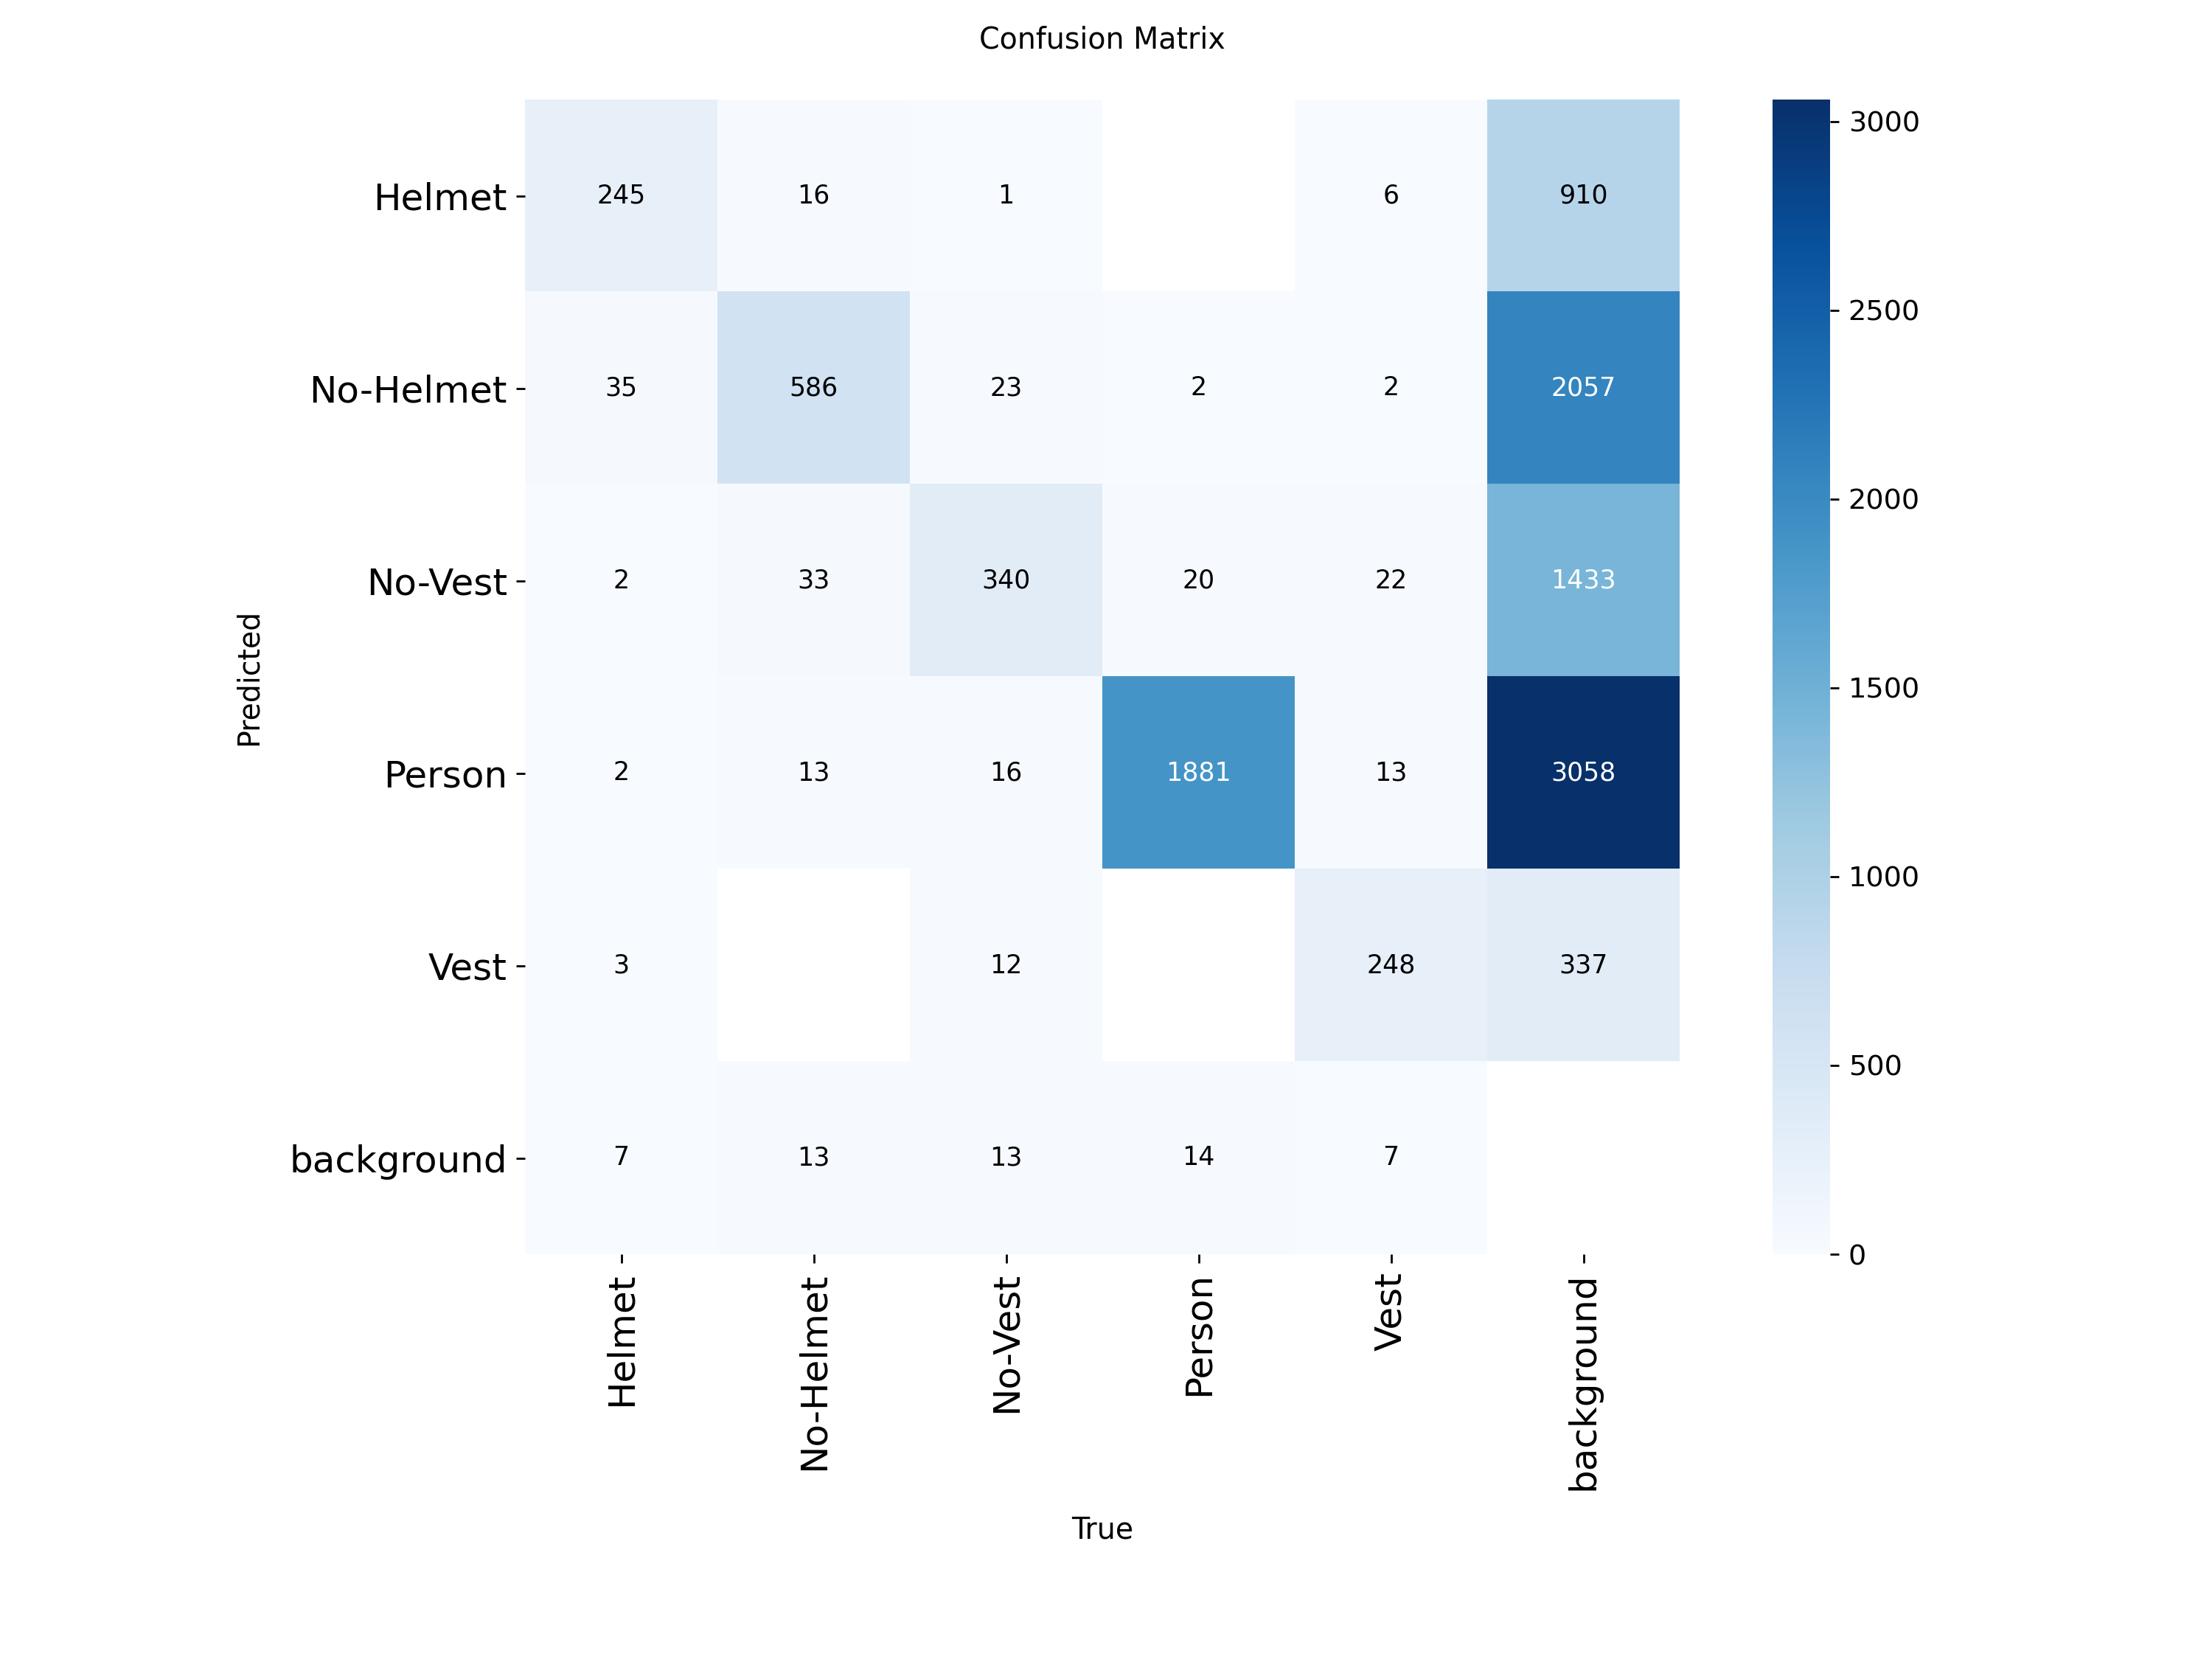


📸 confusion_matrix_normalized.png:


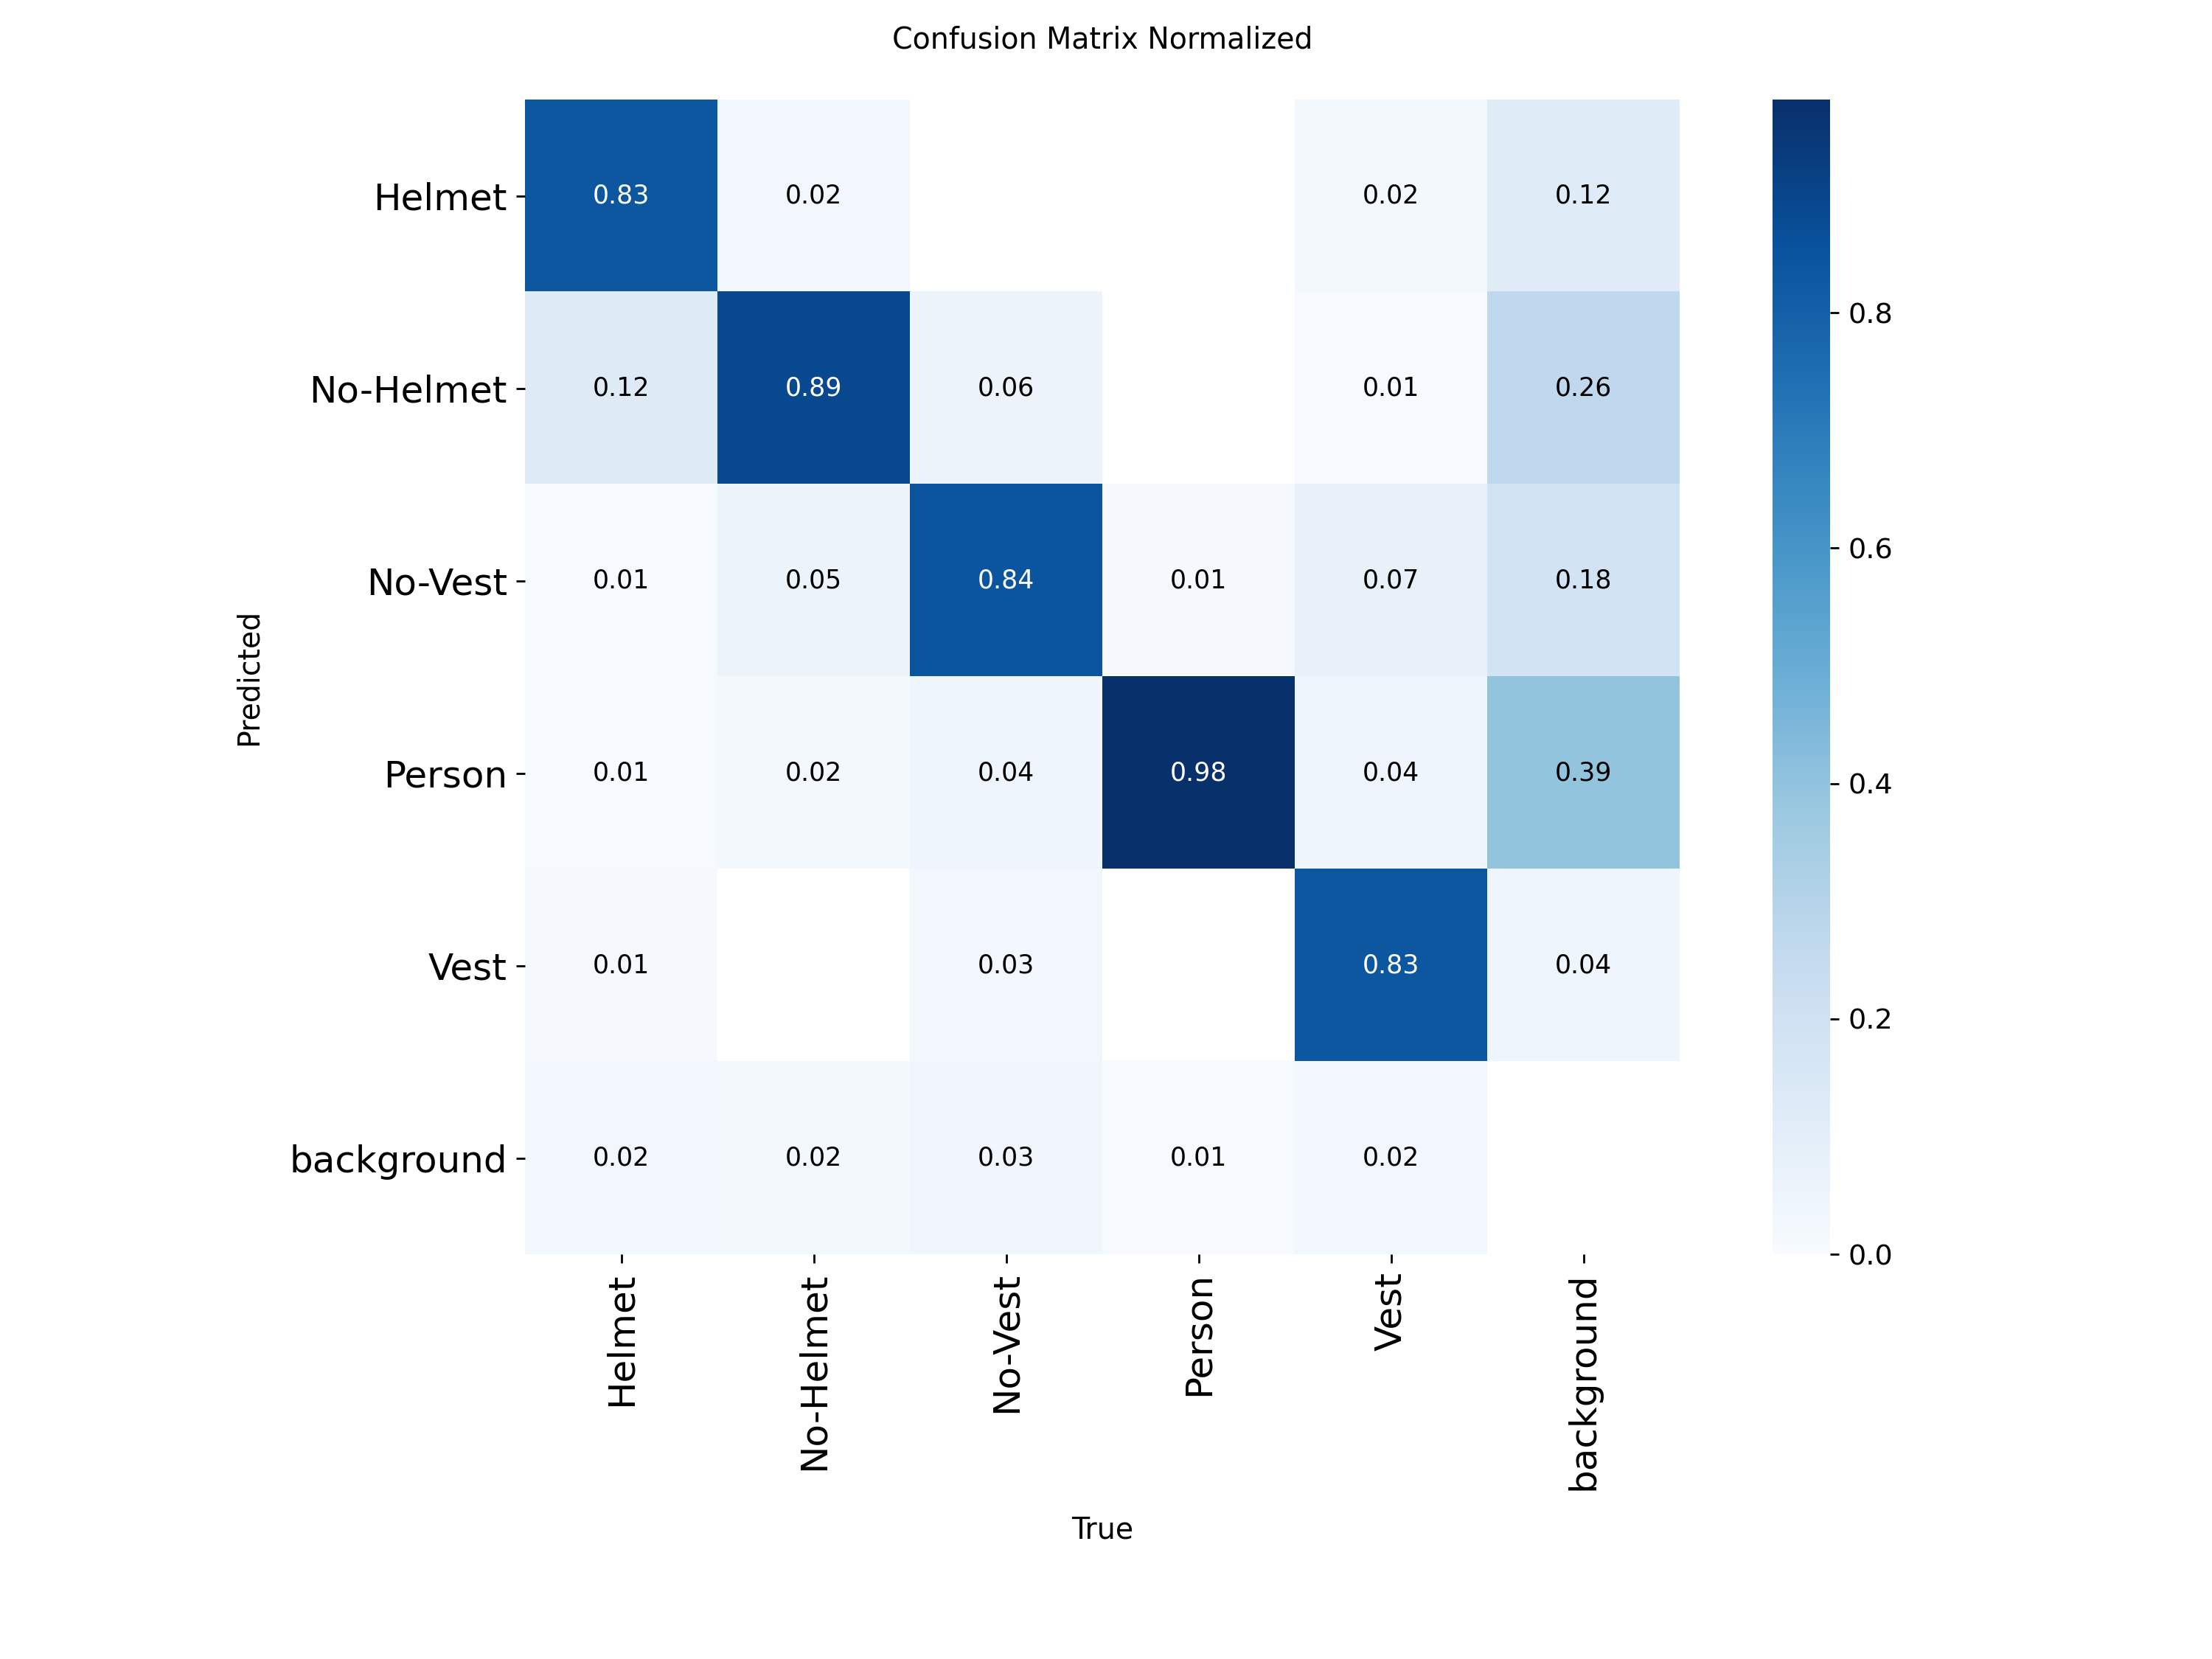

In [6]:
from IPython.display import Image, display

for name in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
    path = RESULTS_DIR / name
    if path.exists():
        print(f"\n📸 {name}:")
        display(Image(filename=str(path), width=700))
    else:
        print(f"⚠️ Not found: {name}")

# 7. Precision-Recall / F1 curves

Display performance curves of the model.


📈 BoxF1_curve.png:

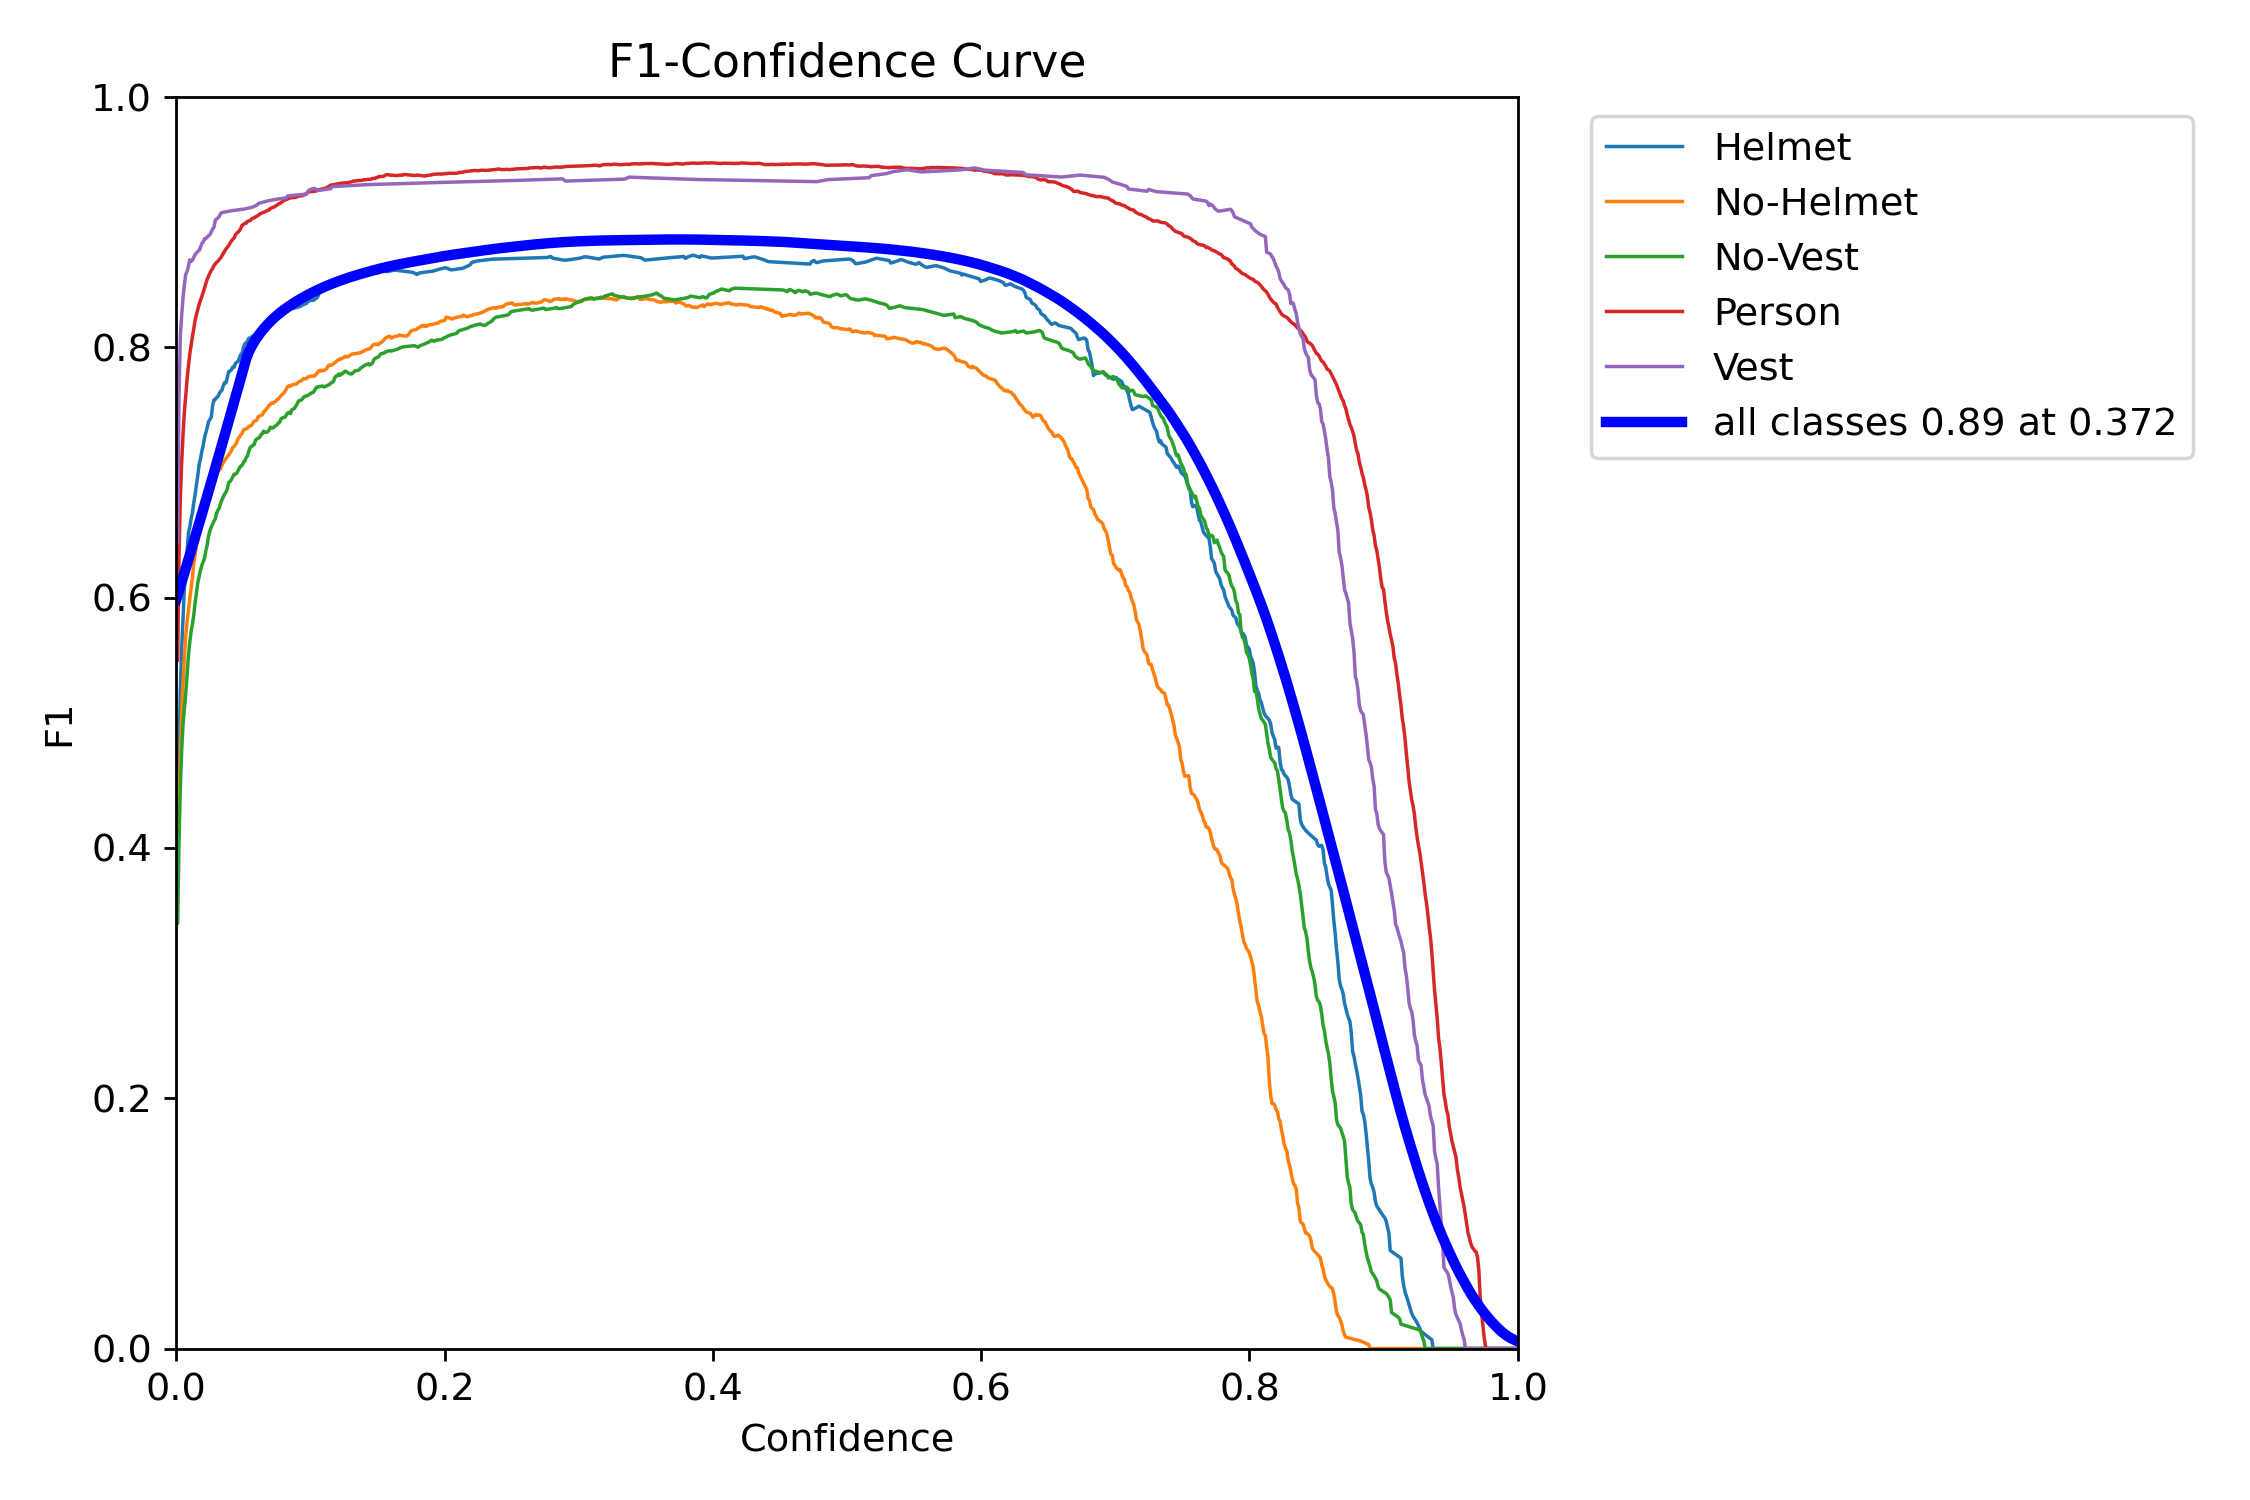


📈 BoxPR_curve.png:


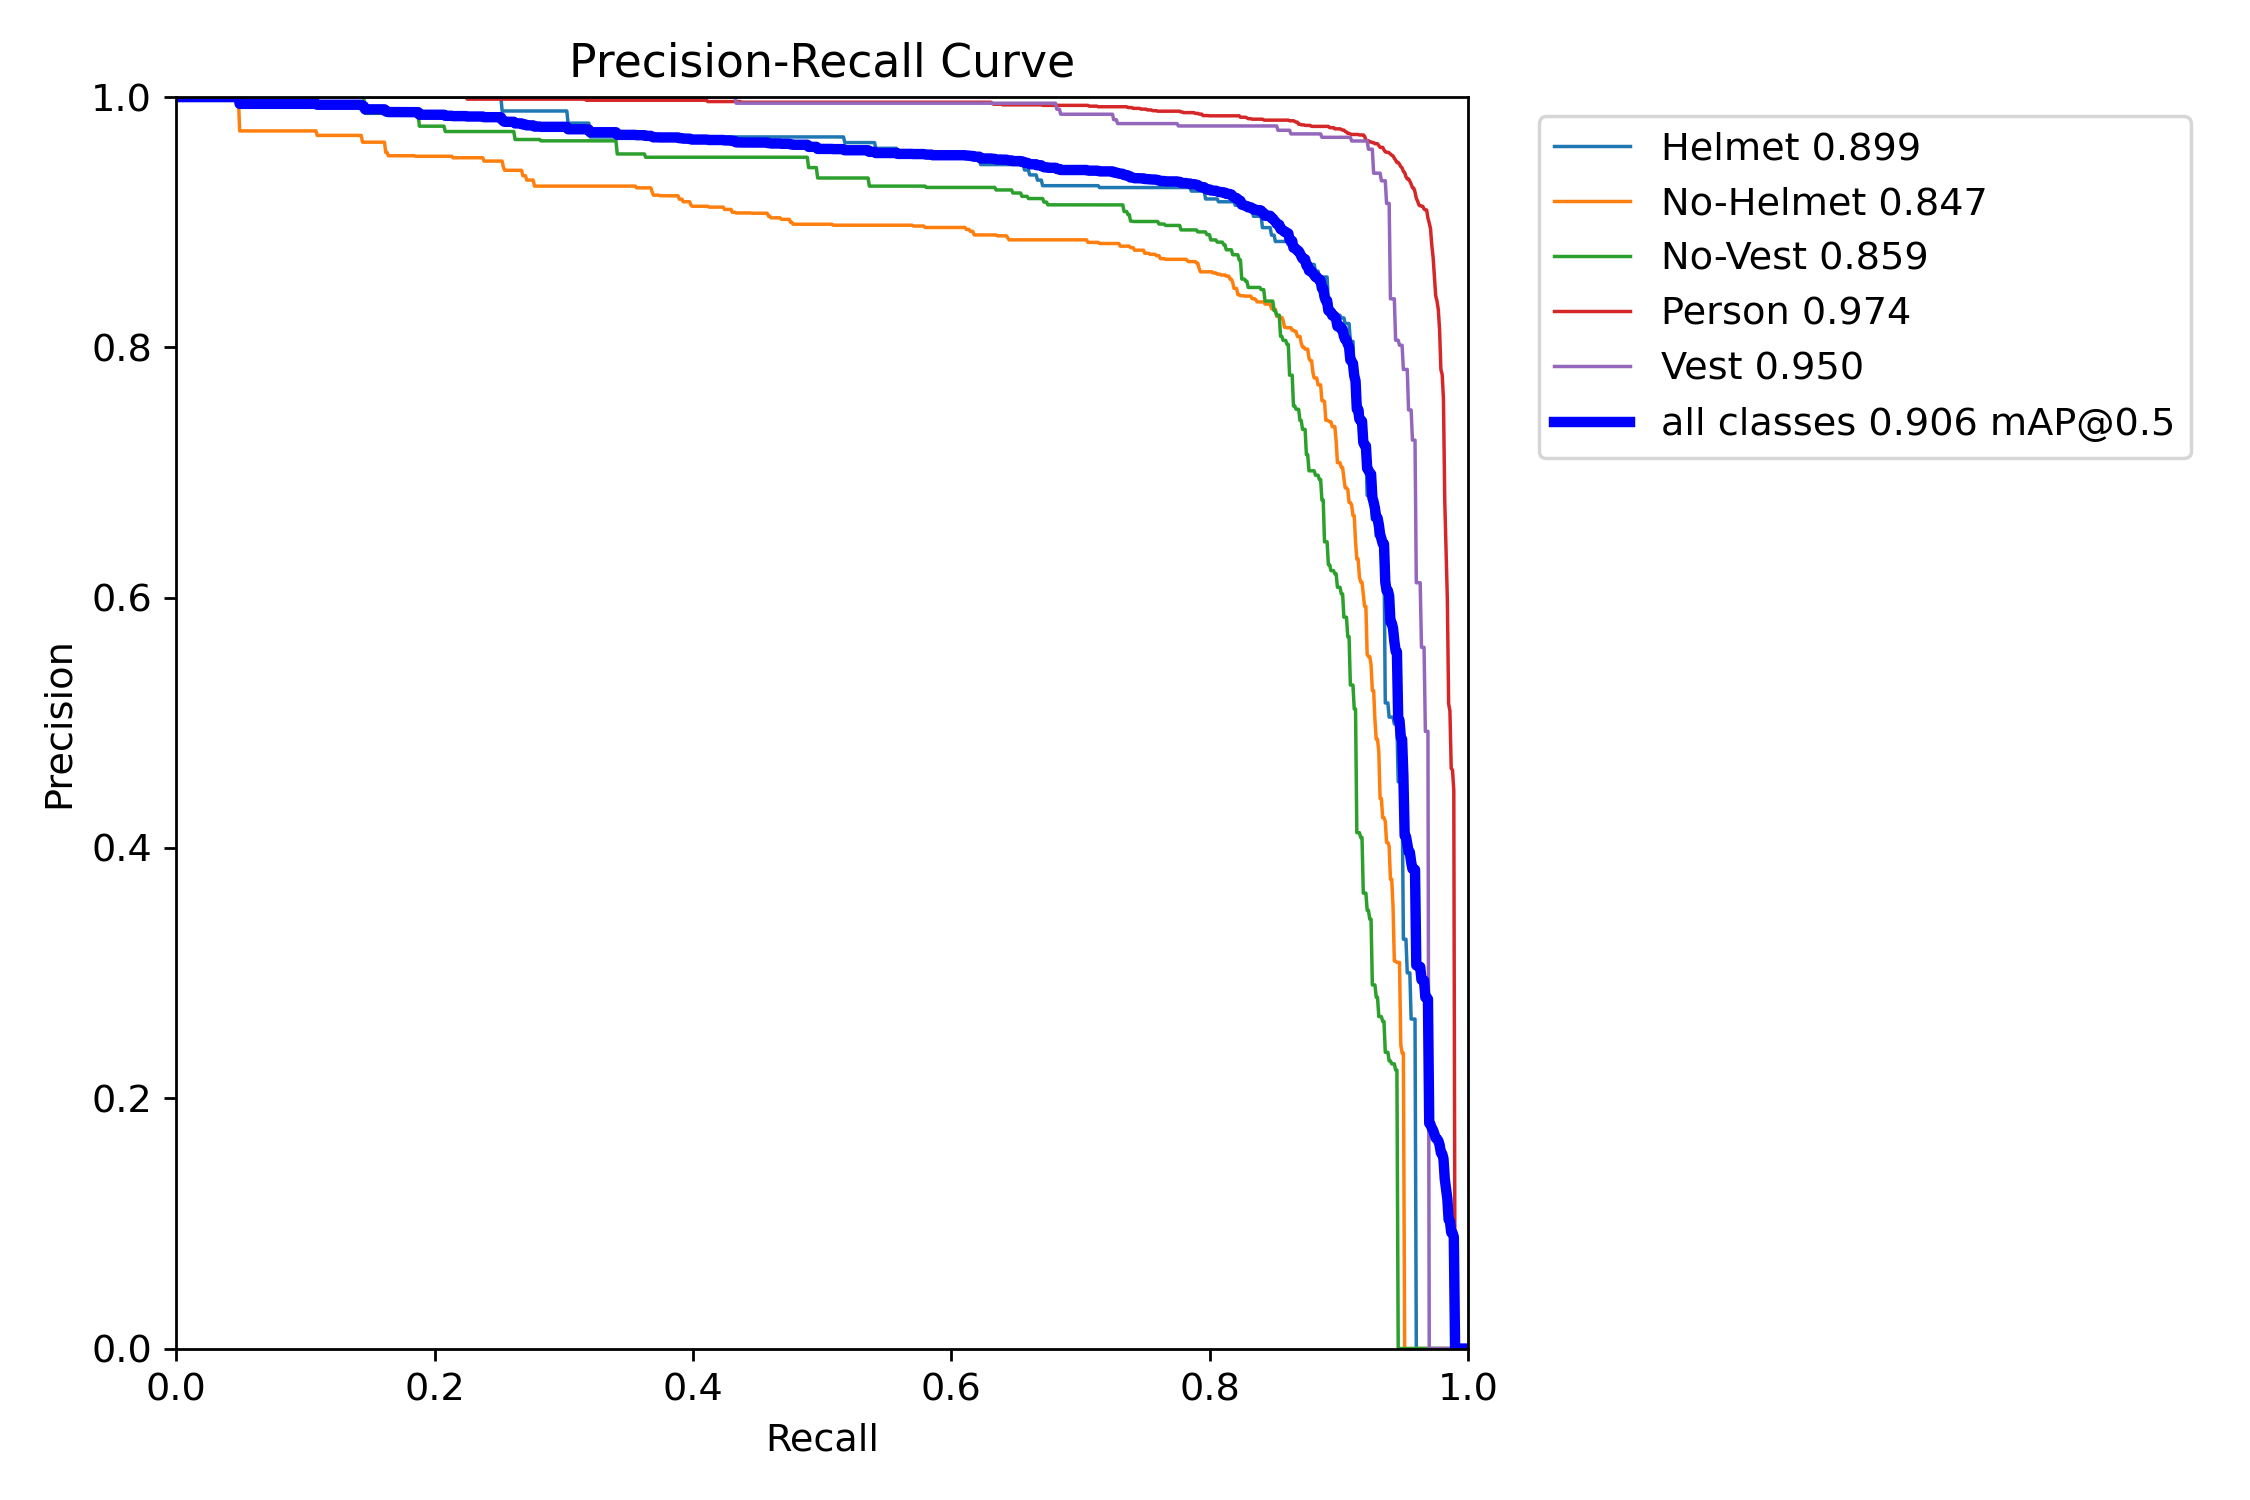


📈 BoxP_curve.png:


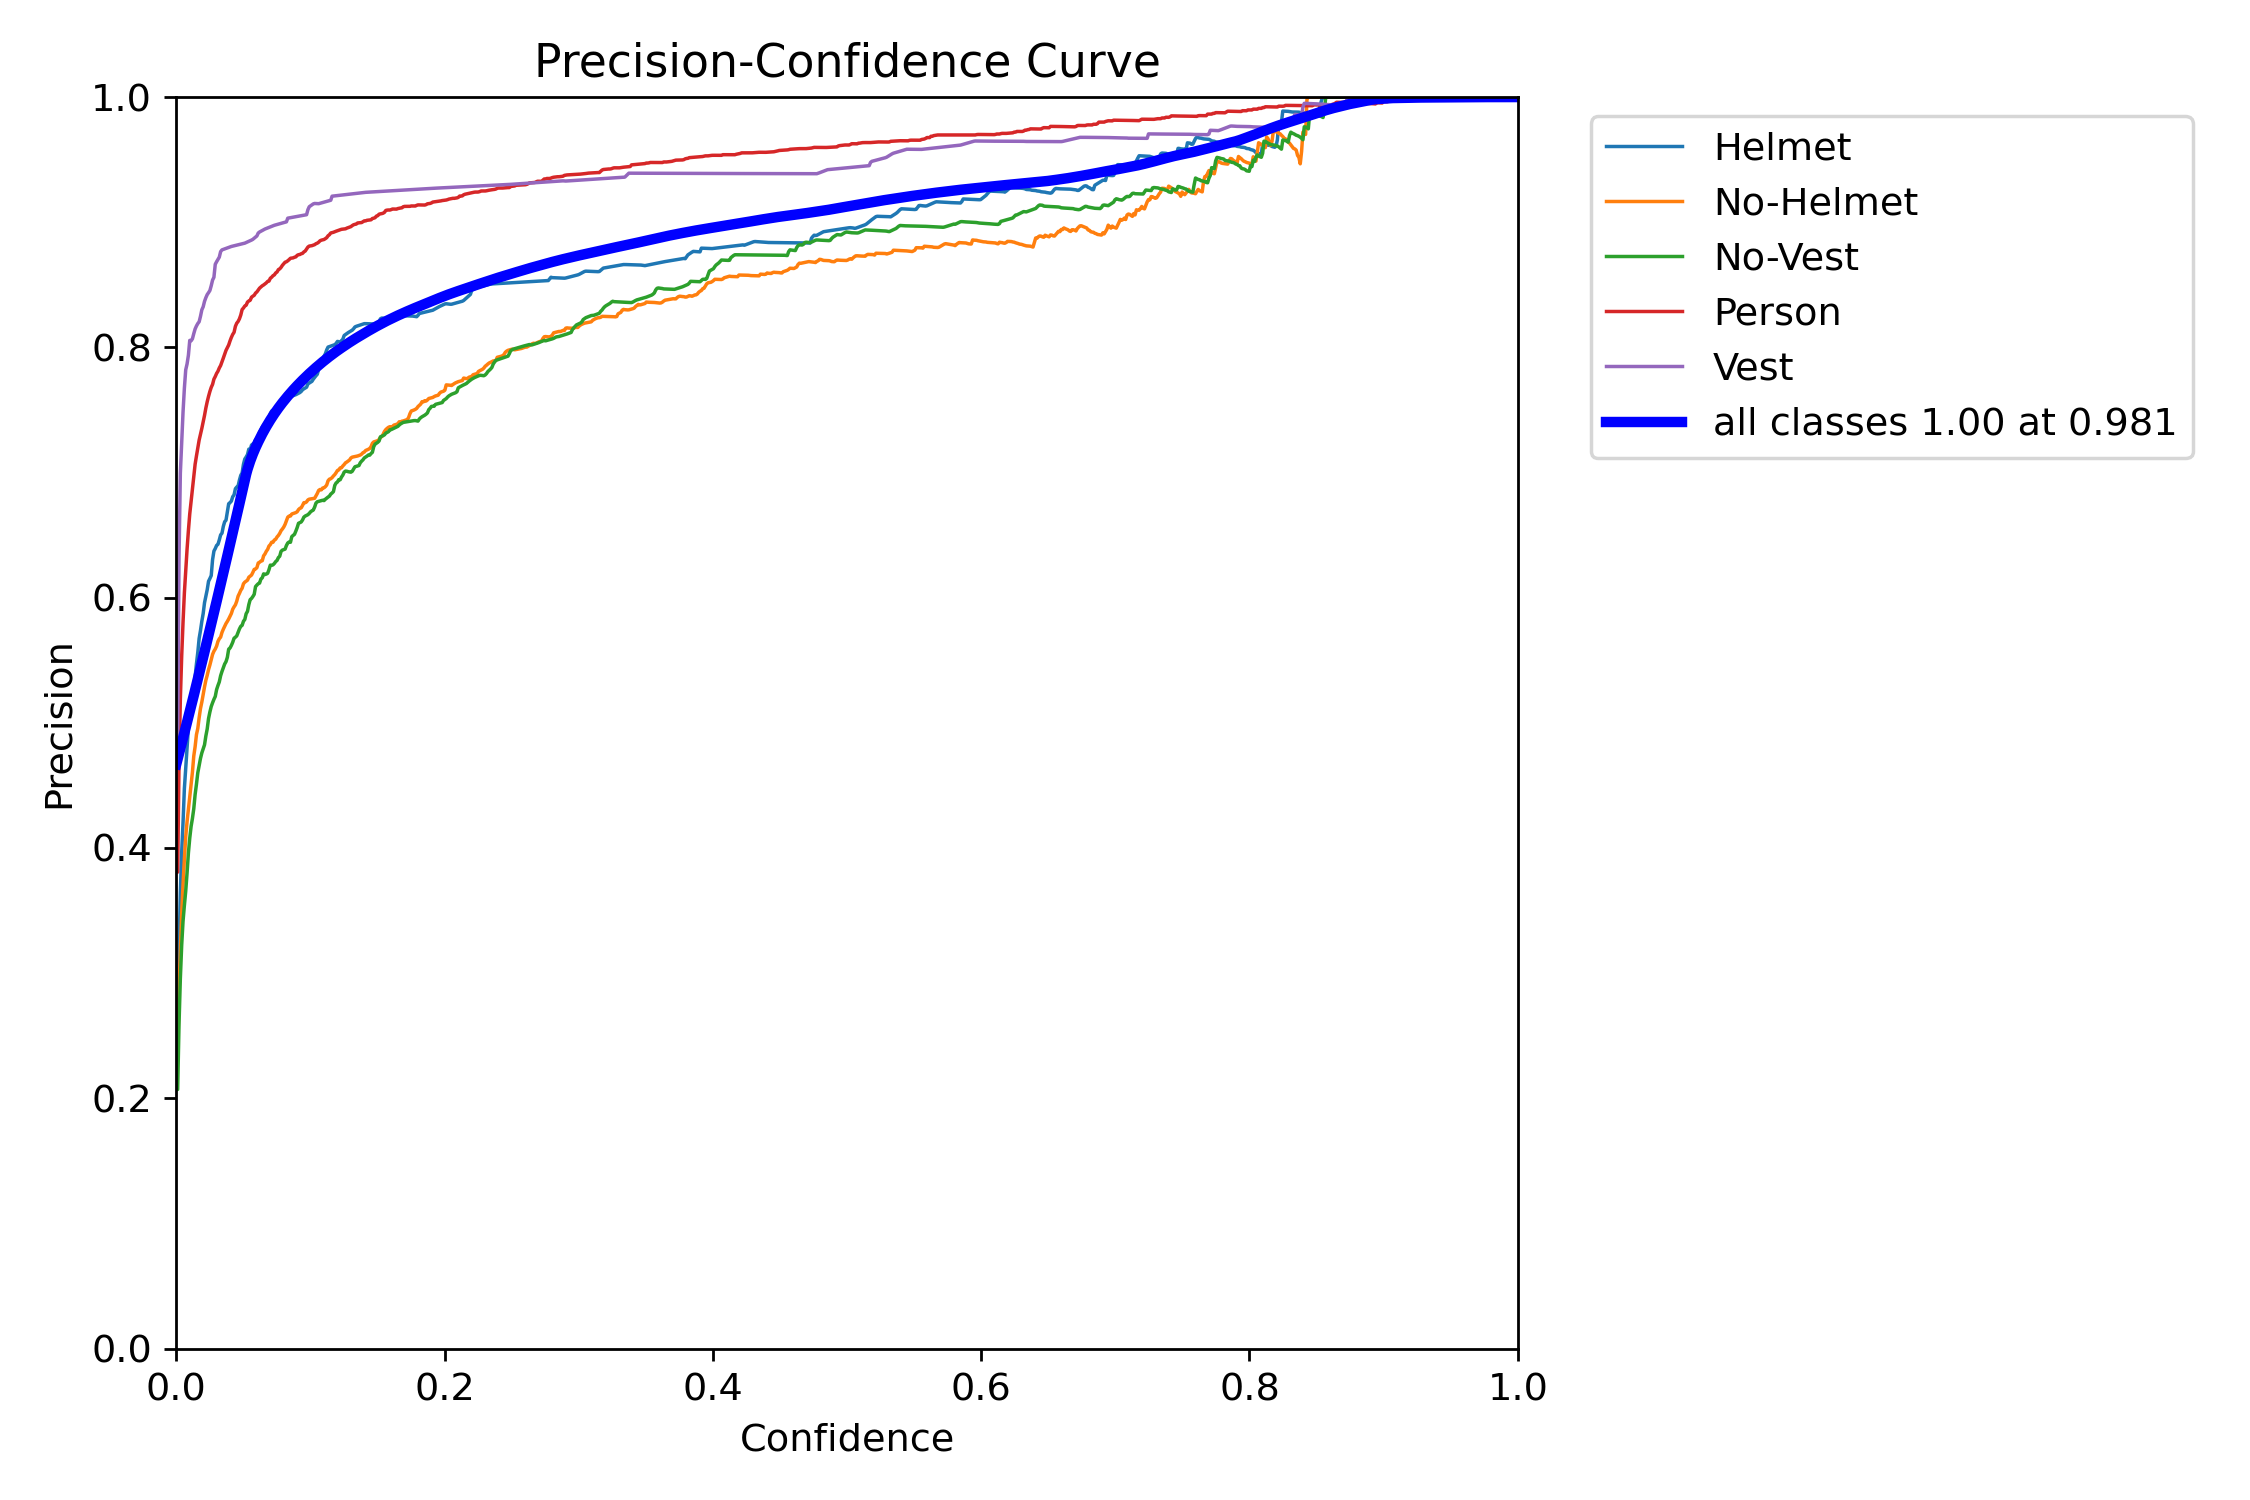


📈 BoxR_curve.png:


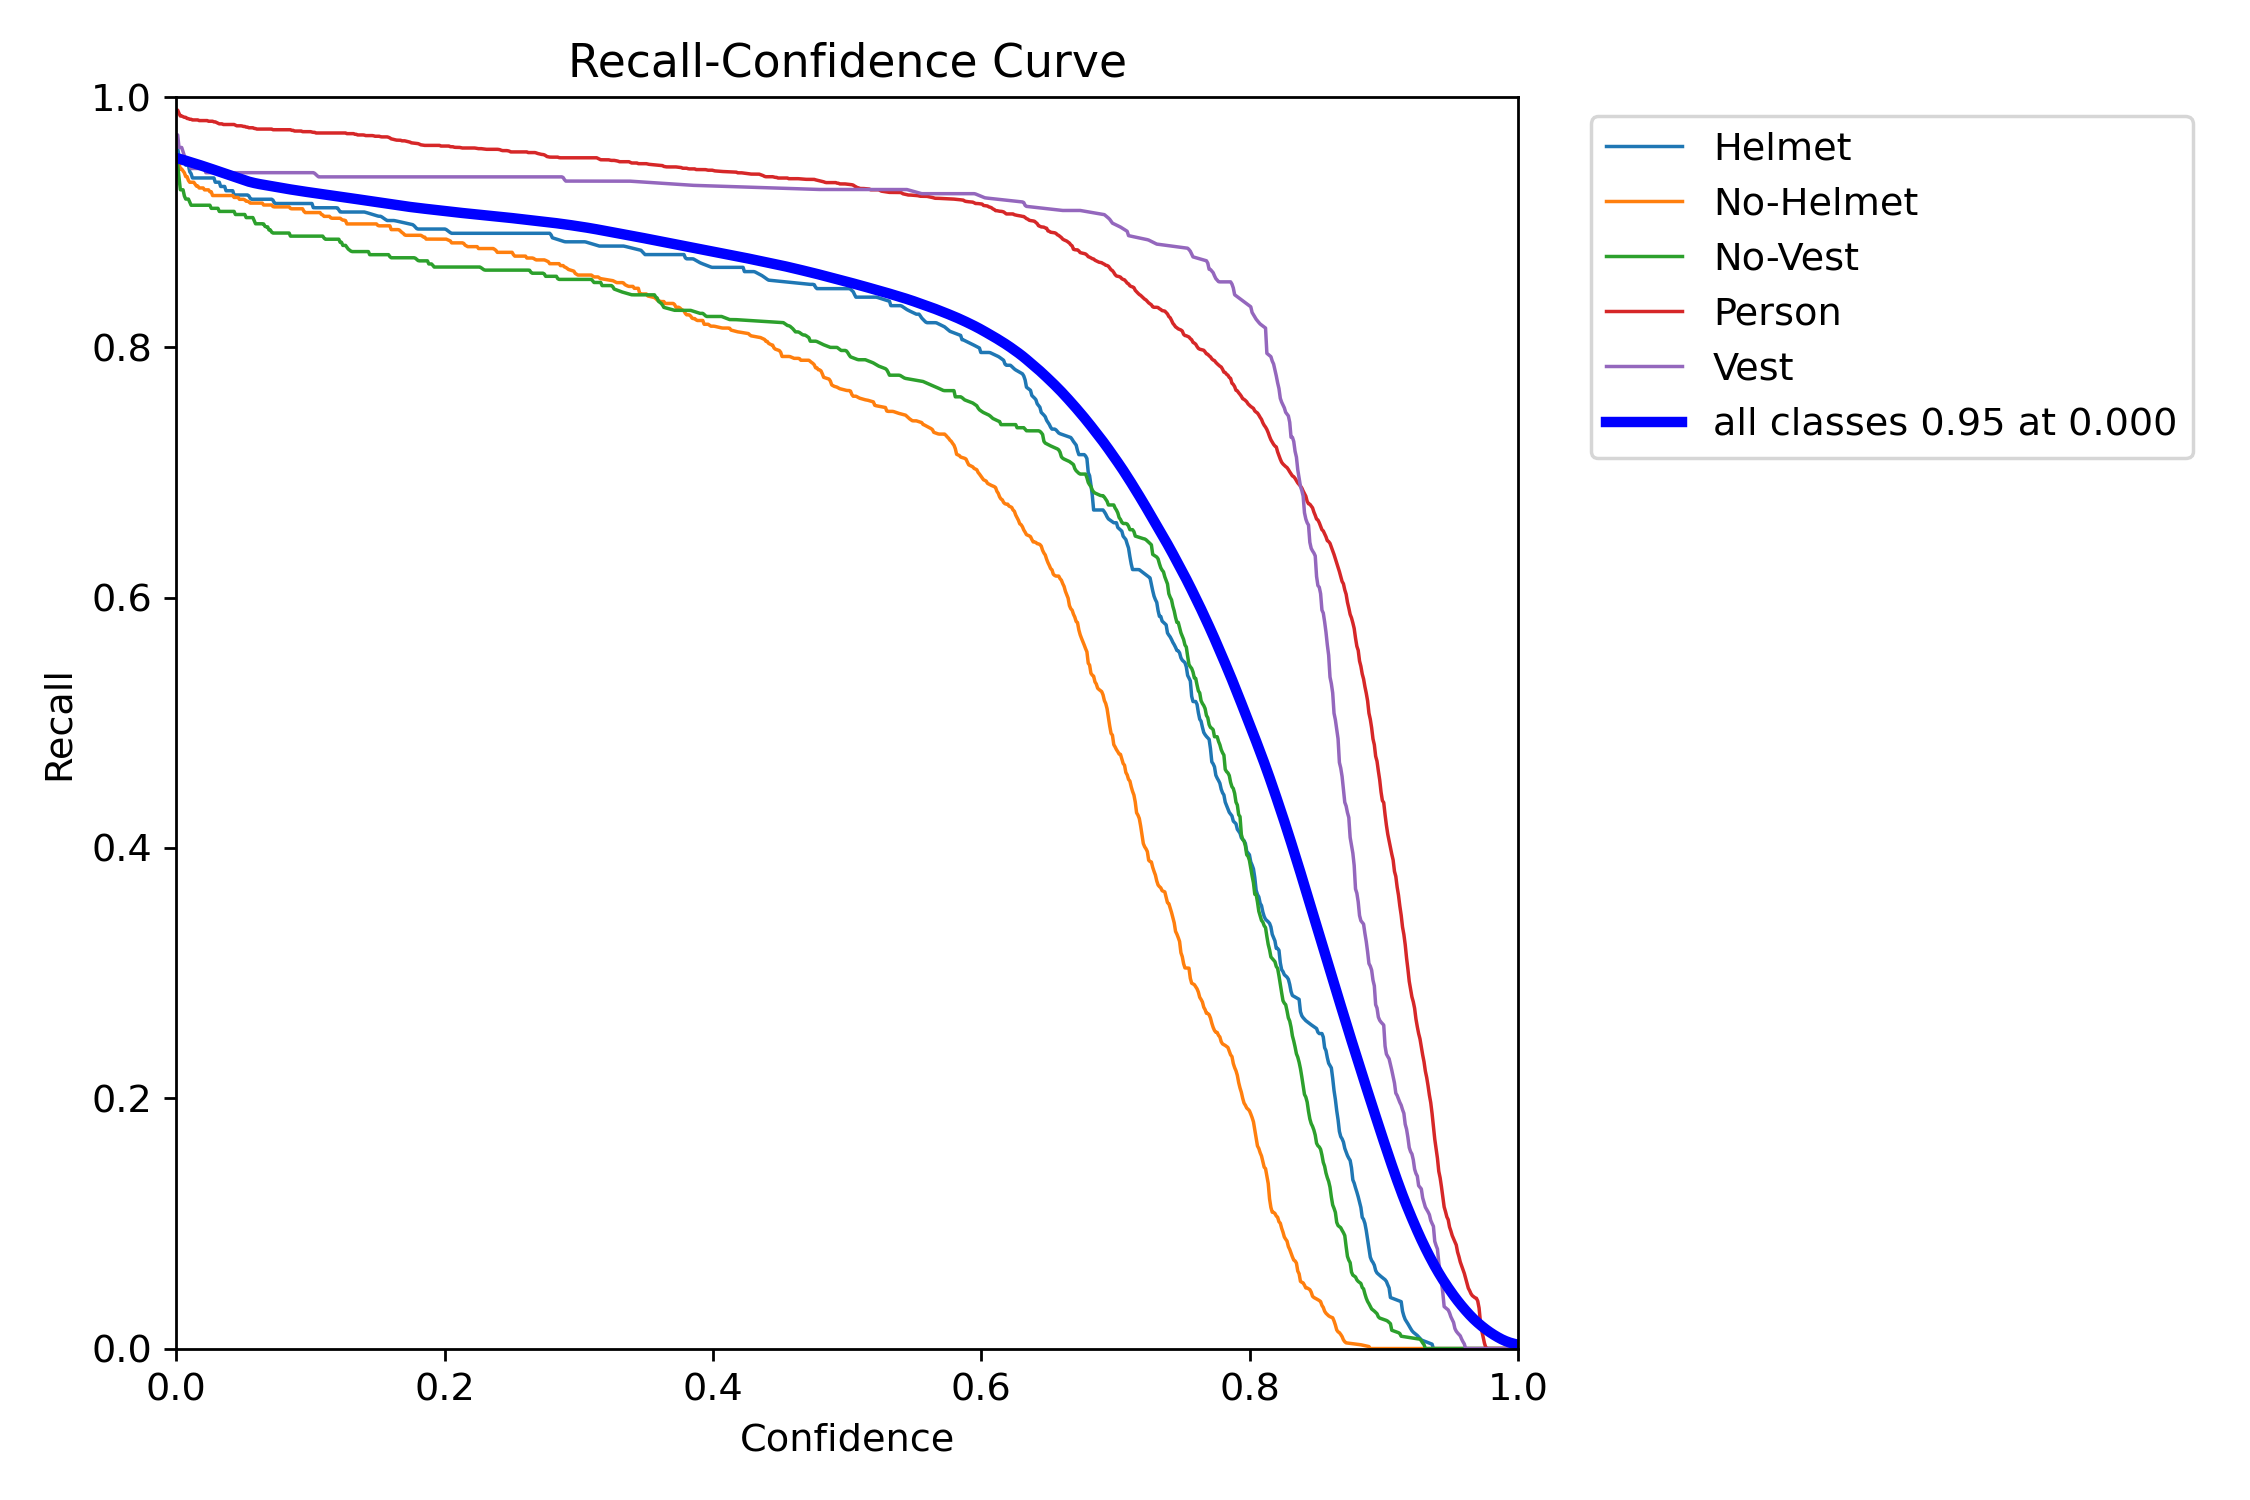

In [7]:
for name in ["BoxF1_curve.png", "BoxPR_curve.png", "BoxP_curve.png", "BoxR_curve.png"]:
    path = RESULTS_DIR / name
    if path.exists():
        print(f"\n📈 {name}:")
        display(Image(filename=str(path), width=750))
    else:
        print(f"⚠️ Not found: {name}")

# 8. Visualize test predictions

Run visual predictions on random sample images from the test set to evaluate real-world performance.

In [8]:
import cv2
import matplotlib.pyplot as plt
import random

test_img_dir = Path("../data/processed/test/images")
test_images = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")) + list(test_img_dir.glob("*.jpeg")))

random.seed(42)
sample_images = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    results = model.predict(img_path, conf=0.25, imgsz=640, verbose=False)[0]
    res_bgr = results.plot()
    res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(res_rgb)
    axes[i].set_title(f"Test Sample {i+1}: {img_path.name}", fontsize=11)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

<Figure size 1800x1200 with 6 Axes>

###  Summary:

- The **YOLO** model achieves strong performance with **Precision = 88.9%**, **Recall = 88.2%**, **mAP50 = 90.6%** on the independent test set.
- The model demonstrates high reliability in detecting workers (`Person`: mAP50 = 97.4%) and safety vests (`Vest`: mAP50 = 95.0%).
- These metrics fully meet requirements for integration into the **Logic Engine (Spatial IoU Association)** and deployment within the **FastAPI Backend + Frontend Web Dashboard** for the PPE Monitoring System.